# OBJETIVO ESPECIFICO 3

**Author:** Andres Felipe Sierra

**Objetivo:** Construcción y análisis del Reaseguro paramétrico para el cumplimiento del Objetivo específico número 3 del proyecto de grado.

**Apreciaciones:** Este script tiene la implementación de la metodología de investigación del proyecto de grado. Por otro lado, este Script tiene el objetivo de presentar netamente los dos primeros modelos del proyecto del objetivo especifico.

## Bussiness understanding

Los datos fueron preparados tomando varias bases de datos, se tuvieron en cuenta La cartografía de Colombia, la fronteras agrícolas, los cultivos de Arroz y de Maíz con el objetivo de generalizar a cualquier cultivo, las precipitaciones, la topografía, cuerpos de agua, entre otros.

Si se quiere saber la preparación se invita a observar en los scrips llamados "Preparacion_..." y "Cartografia_Col". Lo anterior permitió la contrucción de una base práctica y completa para esperar resultados positivos.

## Data understanding

### Libreria

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


### Funciones

In [2]:
def first_existing(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise ValueError(f"No se encontró ninguna columna entre: {candidates}")
    return None


def parse_periodo_columna(s):
    """
    Convierte diferentes formatos de periodo a fecha.
    Acepta formatos como:
    - 2020-01
    - 2020-01-01
    - 202001
    """
    s = s.astype(str).str.replace(r"\.0$", "", regex=True)

    if s.str.fullmatch(r"\d{6}").all():
        return pd.to_datetime(s, format="%Y%m", errors="coerce")
    
    if s.str.fullmatch(r"\d{4}-\d{2}").all():
        return pd.to_datetime(s + "-01", errors="coerce")
    
    return pd.to_datetime(s, errors="coerce")

In [3]:
def calcular_umbrales(
    data,
    indice_col,
    group_cols,
    trigger_q=0.90,
    exit_q=0.98,
    min_obs=24
):
    """
    Calcula trigger y exit por grupo.
    Si un grupo tiene pocas observaciones, usa umbrales globales.
    """
    calib = data.dropna(subset=[indice_col]).copy()

    trigger_global = calib[indice_col].quantile(trigger_q)
    exit_global = calib[indice_col].quantile(exit_q)

    q = (
        calib.groupby(group_cols)[indice_col]
             .quantile([trigger_q, exit_q])
             .unstack()
             .reset_index()
    )

    q.columns = group_cols + ["trigger", "exit"]

    conteos = (
        calib.groupby(group_cols)[indice_col]
             .size()
             .reset_index(name="n_obs_calib")
    )

    q = q.merge(conteos, on=group_cols, how="left")

    # Fallback para grupos con pocas observaciones
    q.loc[q["n_obs_calib"] < min_obs, "trigger"] = trigger_global
    q.loc[q["n_obs_calib"] < min_obs, "exit"] = exit_global

    # Evitar problemas si exit <= trigger
    q.loc[q["exit"] <= q["trigger"], "trigger"] = trigger_global
    q.loc[q["exit"] <= q["trigger"], "exit"] = exit_global

    return q


def calcular_pago_parametrico(indice, trigger, exit_, suma_asegurada):
    """
    Función de pago lineal por tramos:
    0 si índice < trigger
    pago proporcional si trigger <= índice < exit
    suma asegurada si índice >= exit
    """
    denom = exit_ - trigger

    pago = np.where(
        indice < trigger,
        0,
        np.where(
            indice >= exit_,
            suma_asegurada,
            suma_asegurada * (indice - trigger) / denom
        )
    )

    pago = np.where(denom <= 0, 0, pago)
    pago = np.clip(pago, 0, suma_asegurada)

    return pago


def simular_contrato(
    data,
    indice_col,
    trigger_q=0.90,
    exit_q=0.98,
    group_cols=None,
    suma_asegurada=100.0,
    anio_calib_max=2021
):
    """
    Simula un contrato paramétrico.
    Por defecto calcula triggers por municipio.
    """
    if group_cols is None:
        group_cols = [COL_MUNICIPIO]

    base = data.copy()

    calibracion = base[base["anio"] <= anio_calib_max].copy()

    umbrales = calcular_umbrales(
        calibracion,
        indice_col=indice_col,
        group_cols=group_cols,
        trigger_q=trigger_q,
        exit_q=exit_q
    )

    sim = base.merge(umbrales, on=group_cols, how="left")

    sim["suma_asegurada"] = suma_asegurada

    sim["pago_parametrico"] = calcular_pago_parametrico(
        indice=sim[indice_col].values,
        trigger=sim["trigger"].values,
        exit_=sim["exit"].values,
        suma_asegurada=sim["suma_asegurada"].values
    )

    sim["activa_trigger"] = (sim["pago_parametrico"] > 0).astype(int)

    return sim, umbrales

### Dataset panel_modelo_2019_con_EVA

####  Exploración de datos

In [4]:
# -----------------------------
# RUTAS
# -----------------------------
RUTA_BASE = "../Data_preparada/Random-forest_LSTMdata/panel_modelo_2019_2024_con_eva.csv"
CARPETA_SALIDA = "salidas_oe3_parametrico"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

# -----------------------------
# CONFIGURACIÓN GENERAL
# -----------------------------
COL_MUNICIPIO = "codigo_municipio"
COL_NOMBRE_MPIO = "nombre_municipio"
COL_PERIODO = "periodo"

# Si tienes departamento en la base, pon aquí el nombre exacto.
# Si no existe, el script funciona a nivel portafolio nacional.
COL_DEPTO = None  # ejemplo: "nombre_departamento"

# Variable objetivo para backtesting
COL_EVENTO = "hubo_inundacion_agricola_mes"

# Variable de severidad, si existe
COL_SEVERIDAD = "tasa_afectacion_agricola"

# Suma asegurada normalizada.
# Se interpreta como 100 unidades monetarias por municipio.
SUMA_ASEGURADA = 100.0

# Periodo de calibración de triggers
ANIO_CALIB_MAX = 2021

# Escenario base de trigger y exit
TRIGGER_Q = 0.90
EXIT_Q = 0.98

# Índice a utilizar
# "ppt_3m" = precipitación acumulada tres meses
# "anomalia_ppt_3m" = precipitación acumulada tres meses estandarizada
INDICE_BASE = "ppt_3m"

Cargar y validación de datos

In [5]:
df = pd.read_csv(RUTA_BASE)

print("Dimensiones base:", df.shape)
print("Columnas disponibles:")
print(df.columns.tolist())

# -----------------------------
# Columnas clave de tu base
# -----------------------------
COL_MUNICIPIO = "codigo_municipio"
COL_NOMBRE_MPIO = "nombre_municipio"
COL_PERIODO = "periodo"

COL_PPT = "precipitacion_media_mensual_mm"
COL_PPT_3M = "precipitacion_acumulada_3m_mm"

COL_EVENTO = "hubo_inundacion_agricola_mes"
COL_SEVERIDAD = "tasa_afectacion_agricola"

# Índice paramétrico principal para OE3
INDICE_BASE = COL_PPT_3M

SUMA_ASEGURADA = 100.0
ANIO_CALIB_MAX = 2021

TRIGGER_Q = 0.90
EXIT_Q = 0.98

# -----------------------------
# Validación de columnas
# -----------------------------
columnas_necesarias = [
    COL_MUNICIPIO,
    COL_NOMBRE_MPIO,
    COL_PERIODO,
    "anio",
    "mes",
    COL_PPT,
    COL_PPT_3M,
    COL_EVENTO,
    COL_SEVERIDAD
]

faltantes = [c for c in columnas_necesarias if c not in df.columns]

if faltantes:
    raise ValueError(f"Faltan columnas necesarias: {faltantes}")

# -----------------------------
# Conversión de periodo
# -----------------------------
df[COL_PERIODO] = pd.to_datetime(df[COL_PERIODO], errors="coerce")

# Si periodo no convierte bien, reconstruirlo con anio y mes
if df[COL_PERIODO].isna().mean() > 0.1:
    print("Reconstruyendo periodo desde anio y mes...")
    df[COL_PERIODO] = pd.to_datetime(
        df["anio"].astype(str) + "-" + df["mes"].astype(str).str.zfill(2) + "-01",
        errors="coerce"
    )

df["anio"] = df["anio"].astype(int)
df["mes"] = df["mes"].astype(int)

# -----------------------------
# Limpieza mínima
# -----------------------------
df[COL_EVENTO] = df[COL_EVENTO].fillna(0).astype(int)
df[COL_SEVERIDAD] = df[COL_SEVERIDAD].fillna(0)

df[COL_PPT] = pd.to_numeric(df[COL_PPT], errors="coerce")
df[COL_PPT_3M] = pd.to_numeric(df[COL_PPT_3M], errors="coerce")

# Orden
df = df.sort_values([COL_MUNICIPIO, COL_PERIODO]).reset_index(drop=True)

print("Columna de precipitación mensual usada:", COL_PPT)
print("Índice paramétrico usado:", INDICE_BASE)
print("Periodo mínimo:", df[COL_PERIODO].min())
print("Periodo máximo:", df[COL_PERIODO].max())
print("Tasa de eventos:", df[COL_EVENTO].mean())

df[[COL_MUNICIPIO, COL_NOMBRE_MPIO, COL_PERIODO, COL_PPT, INDICE_BASE, COL_EVENTO, COL_SEVERIDAD]].head()

Dimensiones base: (79662, 62)
Columnas disponibles:
['codigo_municipio', 'mes', 'precipitacion_media_mensual_mm', 'anio', 'periodo', 'nombre_municipio', 'codigo_departamento', 'altitud_municipio_m', 'area_municipio_km2', 'longitud_drenajes_km', 'densidad_drenaje_km_km2', 'distancia_drenaje_m', 'proporcion_humedales', 'elevacion_media_m', 'pendiente_media_grados', 'precipitacion_acumulada_3m_mm', 'precipitacion_media_3m_mm', 'percentil_95_precipitacion_municipal_mm', 'indicador_mes_extremo', 'hubo_inundacion_mes', 'hubo_inundacion_agricola_mes', 'numero_eventos_inundacion_mes', 'numero_eventos_agricolas_mes', 'hectareas_afectadas_suma_mes', 'hectareas_afectadas_max_mes', 'personas_afectadas_suma_mes', 'familias_afectadas_suma_mes', 'danio_vivienda_suma_mes', 'danio_infraestructura_suma_mes', 'apoyo_fngrd_suma_mes', 'numero_eventos_con_hectareas_mes', 'numero_eventos_sin_divipola_mes', 'indicador_reporte_hectareas_mes', 'arroz_produccion_t', 'maiz_produccion_t', 'arroz_area_cosechada_ha'

,codigo_municipio,nombre_municipio,periodo,precipitacion_media_mensual_mm,precipitacion_acumulada_3m_mm,hubo_inundacion_agricola_mes,tasa_afectacion_agricola
0,0,Area En Litigio Cauca - Huila,2019-01-01,136.494385,490.446328,0,0.0
1,0,Area En Litigio Cauca - Huila,2019-02-01,107.378072,343.256708,0,0.0
2,0,Area En Litigio Cauca - Huila,2019-03-01,130.574729,374.447186,0,0.0
3,0,Area En Litigio Cauca - Huila,2019-04-01,197.984489,435.937290,0,0.0
4,0,Area En Litigio Cauca - Huila,2019-05-01,161.929389,490.488607,0,0.0


#### Preparación de datos

Construcción y validación del índice paramétrico

In [6]:
df_oe3 = df.dropna(subset=[INDICE_BASE]).copy()

# Anomalía municipal opcional del índice de precipitación acumulada 3m
clima = (
    df_oe3.groupby([COL_MUNICIPIO, "mes"])[INDICE_BASE]
          .agg(media_indice_mensual="mean", sd_indice_mensual="std")
          .reset_index()
)

df_oe3 = df_oe3.merge(
    clima,
    on=[COL_MUNICIPIO, "mes"],
    how="left"
)

df_oe3["anomalia_precipitacion_3m"] = (
    (df_oe3[INDICE_BASE] - df_oe3["media_indice_mensual"]) /
    df_oe3["sd_indice_mensual"].replace(0, np.nan)
)

print("Base OE3:", df_oe3.shape)
print("Índice paramétrico seleccionado:", INDICE_BASE)

df_oe3[
    [
        COL_MUNICIPIO,
        COL_NOMBRE_MPIO,
        COL_PERIODO,
        "anio",
        "mes",
        INDICE_BASE,
        "anomalia_precipitacion_3m",
        COL_EVENTO,
        COL_SEVERIDAD
    ]
].head()

Base OE3: (79520, 65)
Índice paramétrico seleccionado: precipitacion_acumulada_3m_mm


,codigo_municipio,nombre_municipio,periodo,anio,mes,precipitacion_acumulada_3m_mm,anomalia_precipitacion_3m,hubo_inundacion_agricola_mes,tasa_afectacion_agricola
0,0,Area En Litigio Cauca - Huila,2019-01-01,2019,1,490.446328,-0.199098,0,0.0
1,0,Area En Litigio Cauca - Huila,2019-02-01,2019,2,343.256708,-1.025378,0,0.0
2,0,Area En Litigio Cauca - Huila,2019-03-01,2019,3,374.447186,-0.654567,0,0.0
3,0,Area En Litigio Cauca - Huila,2019-04-01,2019,4,435.937290,-0.692667,0,0.0
4,0,Area En Litigio Cauca - Huila,2019-05-01,2019,5,490.488607,-0.133544,0,0.0


Escemario bas - Pagos, burning cost y backtesting.

In [7]:
sim_base, umbrales_base = simular_contrato(
    data=df_oe3,
    indice_col=INDICE_BASE,
    trigger_q=TRIGGER_Q,
    exit_q=EXIT_Q,
    group_cols=[COL_MUNICIPIO],
    suma_asegurada=SUMA_ASEGURADA,
    anio_calib_max=ANIO_CALIB_MAX
)

# Guardar umbrales
umbrales_base.to_csv(
    os.path.join(CARPETA_SALIDA, "umbrales_base_trigger_exit.csv"),
    index=False
)

# Guardar simulación mensual
sim_base.to_csv(
    os.path.join(CARPETA_SALIDA, "simulacion_mensual_parametrica_base.csv"),
    index=False
)

print("Simulación base:")
print(sim_base[[COL_MUNICIPIO, COL_NOMBRE_MPIO, COL_PERIODO, INDICE_BASE,
                "trigger", "exit", "pago_parametrico", COL_EVENTO]].head())

Simulación base:
   codigo_municipio               nombre_municipio    periodo  \
0                 0  Area En Litigio Cauca - Huila 2019-01-01   
1                 0  Area En Litigio Cauca - Huila 2019-02-01   
2                 0  Area En Litigio Cauca - Huila 2019-03-01   
3                 0  Area En Litigio Cauca - Huila 2019-04-01   
4                 0  Area En Litigio Cauca - Huila 2019-05-01   

   precipitacion_acumulada_3m_mm     trigger       exit  pago_parametrico  \
0                     490.446328  503.949411  560.34955               0.0   
1                     343.256708  503.949411  560.34955               0.0   
2                     374.447186  503.949411  560.34955               0.0   
3                     435.937290  503.949411  560.34955               0.0   
4                     490.488607  503.949411  560.34955               0.0   

   hubo_inundacion_agricola_mes  
0                             0  
1                             0  
2                          

Burning cost

In [8]:
# Pago anual por municipio
pago_mun_anual = (
    sim_base.groupby([COL_MUNICIPIO, COL_NOMBRE_MPIO, "anio"])
            .agg(
                pago_anual=("pago_parametrico", "sum"),
                meses_activados=("activa_trigger", "sum"),
                eventos_observados=(COL_EVENTO, "sum")
            )
            .reset_index()
)

# Cap anual: un municipio no paga más de la suma asegurada en el año
pago_mun_anual["pago_anual_cap"] = pago_mun_anual["pago_anual"].clip(
    upper=SUMA_ASEGURADA
)

# Agregado portafolio anual
portafolio_anual = (
    pago_mun_anual.groupby("anio")
                  .agg(
                      pago_total=("pago_anual_cap", "sum"),
                      municipios=("codigo_municipio", "nunique"),
                      eventos_observados=("eventos_observados", "sum"),
                      meses_activados=("meses_activados", "sum")
                  )
                  .reset_index()
)

portafolio_anual["exposicion_total"] = portafolio_anual["municipios"] * SUMA_ASEGURADA
portafolio_anual["burning_cost_pct"] = (
    portafolio_anual["pago_total"] / portafolio_anual["exposicion_total"]
)

prima_pura_pct = portafolio_anual["burning_cost_pct"].mean()
prima_pura_unidades = prima_pura_pct * SUMA_ASEGURADA

print("Burning Cost anual:")
display(portafolio_anual)

print(f"Prima pura promedio como % de suma asegurada: {prima_pura_pct:.4%}")
print(f"Prima pura por 100 unidades aseguradas: {prima_pura_unidades:.4f}")

# Guardar
pago_mun_anual.to_csv(
    os.path.join(CARPETA_SALIDA, "pagos_municipio_anual_base.csv"),
    index=False
)

portafolio_anual.to_csv(
    os.path.join(CARPETA_SALIDA, "burning_cost_portafolio_anual_base.csv"),
    index=False
)

Burning Cost anual:


,anio,pago_total,municipios,eventos_observados,meses_activados,exposicion_total,burning_cost_pct
0,2019,57035.831952,1120,26,1368,112000.0,0.509248
1,2020,61054.614050,1120,62,1477,112000.0,0.545130
2,2021,60835.696591,1120,105,1635,112000.0,0.543176
3,2022,107213.054405,1120,118,5609,112000.0,0.957259
4,2023,58768.092710,1120,49,1646,112000.0,0.524715
5,2024,80499.936732,1120,73,2478,112000.0,0.718749


Prima pura promedio como % de suma asegurada: 63.3046%
Prima pura por 100 unidades aseguradas: 63.3046


Burning cost y prima pura

In [9]:
# Pago anual por municipio
pago_mun_anual = (
    sim_base.groupby([COL_MUNICIPIO, COL_NOMBRE_MPIO, "anio"])
            .agg(
                pago_anual=("pago_parametrico", "sum"),
                meses_activados=("activa_trigger", "sum"),
                eventos_observados=(COL_EVENTO, "sum")
            )
            .reset_index()
)

# Cap anual: un municipio no paga más de la suma asegurada en el año
pago_mun_anual["pago_anual_cap"] = pago_mun_anual["pago_anual"].clip(
    upper=SUMA_ASEGURADA
)

# Agregado portafolio anual
portafolio_anual = (
    pago_mun_anual.groupby("anio")
                  .agg(
                      pago_total=("pago_anual_cap", "sum"),
                      municipios=("codigo_municipio", "nunique"),
                      eventos_observados=("eventos_observados", "sum"),
                      meses_activados=("meses_activados", "sum")
                  )
                  .reset_index()
)

portafolio_anual["exposicion_total"] = portafolio_anual["municipios"] * SUMA_ASEGURADA
portafolio_anual["burning_cost_pct"] = (
    portafolio_anual["pago_total"] / portafolio_anual["exposicion_total"]
)

prima_pura_pct = portafolio_anual["burning_cost_pct"].mean()
prima_pura_unidades = prima_pura_pct * SUMA_ASEGURADA

print("Burning Cost anual:")
display(portafolio_anual)

print(f"Prima pura promedio como % de suma asegurada: {prima_pura_pct:.4%}")
print(f"Prima pura por 100 unidades aseguradas: {prima_pura_unidades:.4f}")

# Guardar
pago_mun_anual.to_csv(
    os.path.join(CARPETA_SALIDA, "pagos_municipio_anual_base.csv"),
    index=False
)

portafolio_anual.to_csv(
    os.path.join(CARPETA_SALIDA, "burning_cost_portafolio_anual_base.csv"),
    index=False
)

Burning Cost anual:


,anio,pago_total,municipios,eventos_observados,meses_activados,exposicion_total,burning_cost_pct
0,2019,57035.831952,1120,26,1368,112000.0,0.509248
1,2020,61054.614050,1120,62,1477,112000.0,0.545130
2,2021,60835.696591,1120,105,1635,112000.0,0.543176
3,2022,107213.054405,1120,118,5609,112000.0,0.957259
4,2023,58768.092710,1120,49,1646,112000.0,0.524715
5,2024,80499.936732,1120,73,2478,112000.0,0.718749


Prima pura promedio como % de suma asegurada: 63.3046%
Prima pura por 100 unidades aseguradas: 63.3046


BACKTESTING Y RIESGO DE BASE

In [10]:
bt = sim_base.copy()

bt["evento_real"] = (bt[COL_EVENTO] > 0).astype(int)
bt["pago_positivo"] = (bt["pago_parametrico"] > 0).astype(int)

# Categoría de resultado
bt["resultado_backtest"] = np.select(
    [
        (bt["evento_real"] == 1) & (bt["pago_positivo"] == 1),
        (bt["evento_real"] == 1) & (bt["pago_positivo"] == 0),
        (bt["evento_real"] == 0) & (bt["pago_positivo"] == 1),
        (bt["evento_real"] == 0) & (bt["pago_positivo"] == 0),
    ],
    [
        "Acierto: evento con pago",
        "Riesgo base adverso: evento sin pago",
        "Riesgo base favorable: pago sin evento",
        "Acierto: sin evento y sin pago",
    ],
    default="Sin clasificar"
)

tabla_backtest = (
    bt["resultado_backtest"]
      .value_counts()
      .rename_axis("resultado")
      .reset_index(name="n")
)

tabla_backtest["porcentaje"] = tabla_backtest["n"] / tabla_backtest["n"].sum()

display(tabla_backtest)

# Métricas resumen
tp = ((bt["evento_real"] == 1) & (bt["pago_positivo"] == 1)).sum()
fn = ((bt["evento_real"] == 1) & (bt["pago_positivo"] == 0)).sum()
fp = ((bt["evento_real"] == 0) & (bt["pago_positivo"] == 1)).sum()
tn = ((bt["evento_real"] == 0) & (bt["pago_positivo"] == 0)).sum()

hit_rate = tp / (tp + fn) if (tp + fn) > 0 else np.nan
precision_param = tp / (tp + fp) if (tp + fp) > 0 else np.nan
riesgo_base_adverso = fn / (tp + fn) if (tp + fn) > 0 else np.nan
tasa_falsa_activacion = fp / (fp + tn) if (fp + tn) > 0 else np.nan

metricas_backtest = pd.DataFrame({
    "metrica": [
        "Hit rate / eventos capturados",
        "Precisión paramétrica",
        "Riesgo base adverso",
        "Tasa de falsa activación"
    ],
    "valor": [
        hit_rate,
        precision_param,
        riesgo_base_adverso,
        tasa_falsa_activacion
    ]
})

display(metricas_backtest)

# Guardar
tabla_backtest.to_csv(
    os.path.join(CARPETA_SALIDA, "tabla_backtesting_riesgo_base.csv"),
    index=False
)

metricas_backtest.to_csv(
    os.path.join(CARPETA_SALIDA, "metricas_backtesting_riesgo_base.csv"),
    index=False
)

bt.to_csv(
    os.path.join(CARPETA_SALIDA, "backtesting_detallado_base.csv"),
    index=False
)

,resultado,n,porcentaje
0,Acierto: sin evento y sin pago,65033,0.817819
1,Riesgo base favorable: pago sin evento,14054,0.176735
2,Riesgo base adverso: evento sin pago,274,0.003446
3,Acierto: evento con pago,159,0.001999


,metrica,valor
0,Hit rate / eventos capturados,0.367206
1,Precisión paramétrica,0.011187
2,Riesgo base adverso,0.632794
3,Tasa de falsa activación,0.177703


Estructura de reaseguro no proporcional

In [11]:
# Agregación anual del portafolio
agregado = portafolio_anual.copy()

# Calibrar prioridad y límite con años de calibración
calib_agg = agregado[agregado["anio"] <= ANIO_CALIB_MAX].copy()

PRIORIDAD_Q = 0.90
LIMITE_Q = 0.99

prioridad = calib_agg["pago_total"].quantile(PRIORIDAD_Q)
pago_extremo = calib_agg["pago_total"].quantile(LIMITE_Q)

# Límite de la capa
limite = max(pago_extremo - prioridad, 0)

# Si no hay suficiente variabilidad histórica, usar regla alternativa
if limite == 0 or np.isnan(limite):
    limite = prioridad

agregado["recuperacion_reaseguro"] = np.minimum(
    np.maximum(agregado["pago_total"] - prioridad, 0),
    limite
)

agregado["retencion_cedente"] = agregado["pago_total"] - agregado["recuperacion_reaseguro"]

prima_pura_reaseguro = agregado["recuperacion_reaseguro"].mean()

print("Prioridad de la capa:", prioridad)
print("Límite de la capa:", limite)
print("Prima pura del reaseguro:", prima_pura_reaseguro)

display(agregado)

agregado.to_csv(
    os.path.join(CARPETA_SALIDA, "estructura_reaseguro_stoploss_catxl.csv"),
    index=False
)

Prioridad de la capa: 61010.830558380905
Límite de la capa: 39.40514262695069
Prima pura del reaseguro: 19.702571313475346


,anio,pago_total,municipios,eventos_observados,meses_activados,exposicion_total,burning_cost_pct,recuperacion_reaseguro,retencion_cedente
0,2019,57035.831952,1120,26,1368,112000.0,0.509248,0.000000,57035.831952
1,2020,61054.614050,1120,62,1477,112000.0,0.545130,39.405143,61015.208908
2,2021,60835.696591,1120,105,1635,112000.0,0.543176,0.000000,60835.696591
3,2022,107213.054405,1120,118,5609,112000.0,0.957259,39.405143,107173.649262
4,2023,58768.092710,1120,49,1646,112000.0,0.524715,0.000000,58768.092710
5,2024,80499.936732,1120,73,2478,112000.0,0.718749,39.405143,80460.531590


Análisis de sensibilidad

In [12]:
escenarios = [
    {"escenario": "Amplio", "trigger_q": 0.85, "exit_q": 0.95},
    {"escenario": "Base", "trigger_q": 0.90, "exit_q": 0.98},
    {"escenario": "Estricto", "trigger_q": 0.95, "exit_q": 0.99},
]

resumen_escenarios = []
simulaciones_escenarios = []

for e in escenarios:
    sim_e, umbrales_e = simular_contrato(
        data=df_oe3,
        indice_col=INDICE_BASE,
        trigger_q=e["trigger_q"],
        exit_q=e["exit_q"],
        group_cols=[COL_MUNICIPIO],
        suma_asegurada=SUMA_ASEGURADA,
        anio_calib_max=ANIO_CALIB_MAX
    )

    sim_e["escenario"] = e["escenario"]
    simulaciones_escenarios.append(sim_e)

    # Backtesting
    evento_real = (sim_e[COL_EVENTO] > 0).astype(int)
    pago_positivo = (sim_e["pago_parametrico"] > 0).astype(int)

    tp = ((evento_real == 1) & (pago_positivo == 1)).sum()
    fn = ((evento_real == 1) & (pago_positivo == 0)).sum()
    fp = ((evento_real == 0) & (pago_positivo == 1)).sum()
    tn = ((evento_real == 0) & (pago_positivo == 0)).sum()

    hit_rate = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision_param = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    riesgo_base_adverso = fn / (tp + fn) if (tp + fn) > 0 else np.nan

    # Burning cost anual
    pago_mun_anual_e = (
        sim_e.groupby([COL_MUNICIPIO, "anio"])
             .agg(pago_anual=("pago_parametrico", "sum"))
             .reset_index()
    )

    pago_mun_anual_e["pago_anual_cap"] = pago_mun_anual_e["pago_anual"].clip(
        upper=SUMA_ASEGURADA
    )

    port_anual_e = (
        pago_mun_anual_e.groupby("anio")
                        .agg(
                            pago_total=("pago_anual_cap", "sum"),
                            municipios=(COL_MUNICIPIO, "nunique")
                        )
                        .reset_index()
    )

    port_anual_e["exposicion_total"] = port_anual_e["municipios"] * SUMA_ASEGURADA
    port_anual_e["burning_cost_pct"] = (
        port_anual_e["pago_total"] / port_anual_e["exposicion_total"]
    )

    resumen_escenarios.append({
        "escenario": e["escenario"],
        "trigger_q": e["trigger_q"],
        "exit_q": e["exit_q"],
        "prima_pura_pct": port_anual_e["burning_cost_pct"].mean(),
        "frecuencia_activacion": sim_e["activa_trigger"].mean(),
        "hit_rate": hit_rate,
        "precision_parametrica": precision_param,
        "riesgo_base_adverso": riesgo_base_adverso,
        "pago_promedio_anual": port_anual_e["pago_total"].mean()
    })

resumen_escenarios = pd.DataFrame(resumen_escenarios)
simulaciones_escenarios = pd.concat(simulaciones_escenarios, ignore_index=True)

display(resumen_escenarios)

resumen_escenarios.to_csv(
    os.path.join(CARPETA_SALIDA, "resumen_escenarios_sensibilidad.csv"),
    index=False
)

simulaciones_escenarios.to_csv(
    os.path.join(CARPETA_SALIDA, "simulaciones_escenarios_sensibilidad.csv"),
    index=False
)

,escenario,trigger_q,exit_q,prima_pura_pct,frecuencia_activacion,hit_rate,precision_parametrica,riesgo_base_adverso,pago_promedio_anual
0,Amplio,0.85,0.95,0.754700,0.230433,0.438799,0.010369,0.561201,84526.404536
1,Base,0.90,0.98,0.633046,0.178735,0.367206,0.011187,0.632794,70901.204407
2,Estricto,0.95,0.99,0.527022,0.123466,0.300231,0.013241,0.699769,59026.462794


#### Gráficas

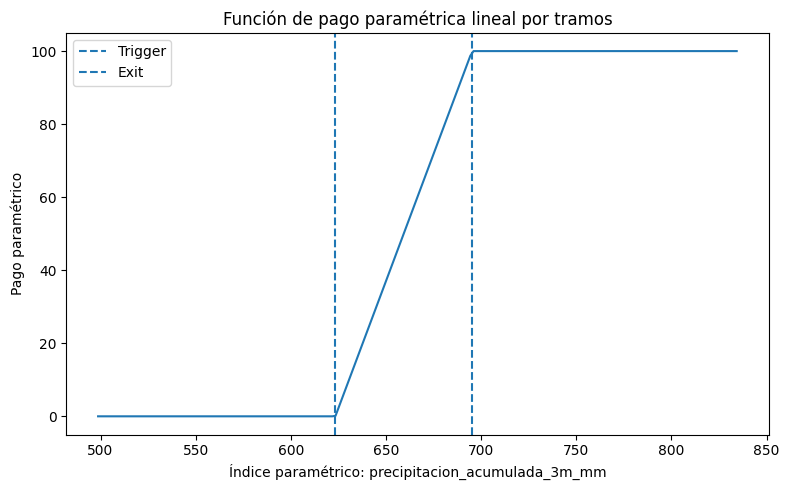

In [13]:
# FUNCIÓN DE PAGO PARAMÉTRICA

trigger_mediano = umbrales_base["trigger"].median()
exit_mediano = umbrales_base["exit"].median()

x = np.linspace(
    trigger_mediano * 0.8,
    exit_mediano * 1.2,
    200
)

y = calcular_pago_parametrico(
    indice=x,
    trigger=trigger_mediano,
    exit_=exit_mediano,
    suma_asegurada=SUMA_ASEGURADA
)

plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.axvline(trigger_mediano, linestyle="--", label="Trigger")
plt.axvline(exit_mediano, linestyle="--", label="Exit")
plt.xlabel(f"Índice paramétrico: {INDICE_BASE}")
plt.ylabel("Pago paramétrico")
plt.title("Función de pago paramétrica lineal por tramos")
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(CARPETA_SALIDA, "figura_funcion_pago_parametrica.png"),
    dpi=300
)

plt.show()

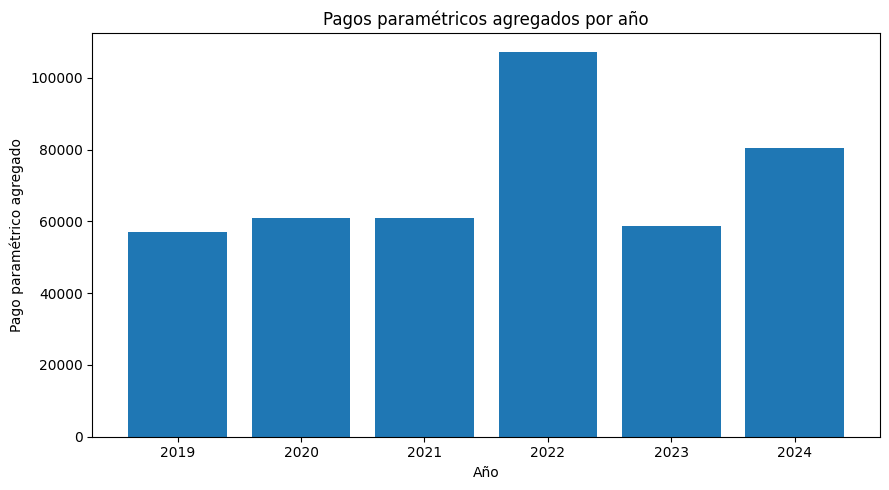

In [14]:
# FIGURA: PAGOS ANUALES SIMULADOS

plt.figure(figsize=(9, 5))
plt.bar(portafolio_anual["anio"], portafolio_anual["pago_total"])
plt.xlabel("Año")
plt.ylabel("Pago paramétrico agregado")
plt.title("Pagos paramétricos agregados por año")
plt.tight_layout()

plt.savefig(
    os.path.join(CARPETA_SALIDA, "figura_pagos_anuales_parametricos.png"),
    dpi=300
)

plt.show()

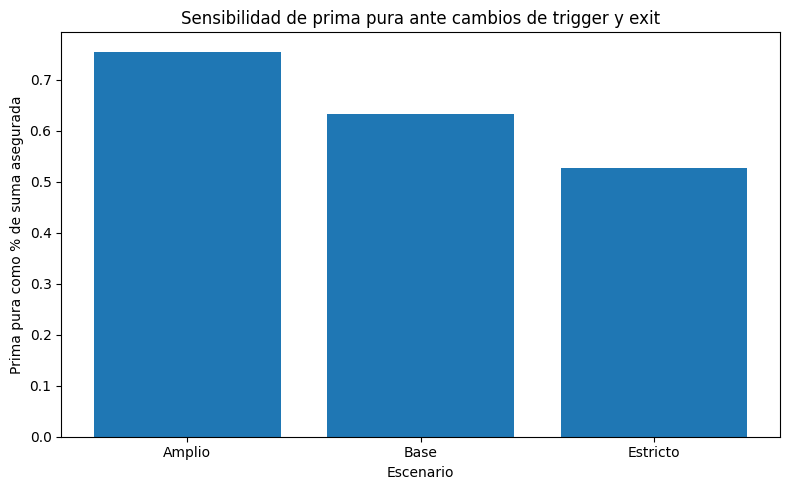

In [15]:
# FIGURA: SENSIBILIDAD DE PRIMA PURA

plt.figure(figsize=(8, 5))
plt.bar(resumen_escenarios["escenario"], resumen_escenarios["prima_pura_pct"])
plt.xlabel("Escenario")
plt.ylabel("Prima pura como % de suma asegurada")
plt.title("Sensibilidad de prima pura ante cambios de trigger y exit")
plt.tight_layout()

plt.savefig(
    os.path.join(CARPETA_SALIDA, "figura_sensibilidad_prima_pura.png"),
    dpi=300
)

plt.show()

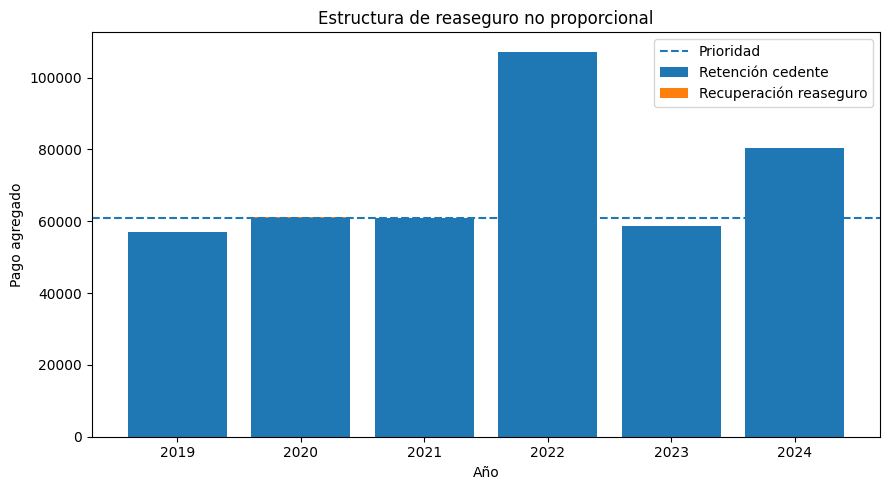

In [16]:
# FIGURA: RETENCIÓN Y RECUPERACIÓN DE REASEGURO

plt.figure(figsize=(9, 5))
plt.bar(agregado["anio"], agregado["retencion_cedente"], label="Retención cedente")
plt.bar(
    agregado["anio"],
    agregado["recuperacion_reaseguro"],
    bottom=agregado["retencion_cedente"],
    label="Recuperación reaseguro"
)
plt.axhline(prioridad, linestyle="--", label="Prioridad")
plt.xlabel("Año")
plt.ylabel("Pago agregado")
plt.title("Estructura de reaseguro no proporcional")
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(CARPETA_SALIDA, "figura_capa_reaseguro.png"),
    dpi=300
)

plt.show()

### Dataset IMRC del DNP

#### Exploración de datos

Cargue de datos

In [17]:
RUTA_IMRC = "../Data/DNP/IMRC-BASE-DE-DATOS-2024.xlsx"

imrc = pd.read_excel(
    RUTA_IMRC,
    sheet_name="Exceso de Lluvias",
    header=1
)

# Eliminar columnas completamente vacías
imrc = imrc.dropna(axis=1, how="all")

# Limpiar nombres de columnas
imrc.columns = (
    imrc.columns
        .astype(str)
        .str.strip()
        .str.replace("\n", " ", regex=False)
        .str.replace(r"\s+", " ", regex=True)
)

print("Dimensiones IMRC:", imrc.shape)
print(imrc.columns.tolist())

# Revisar primeras filas
imrc.head()

Dimensiones IMRC: (1123, 28)
['ID', 'Cód DPTO', 'Departamento', 'DIVIPOLA', 'Municipio', 'Tipo de Municipio', 'Area amenazada Exceso (AA) has', '%AA', 'Poblacion Expuesta a exceso (PE)', '%PE', 'Vulnerabilidad social (% IPM)', 'Indice de Rieso de Desastres Exceso (IR_E)', 'Valor Agregado Promedio per capita (2016 - 2019) Precios constantes del 2019', 'Porcentaje Población en Cabecera 2019', 'Densidad Empresarial (2019)', 'Componente socioeconómico', 'Promedio de los Ingresos tributarios y no tributarios per capita (2016 - 2019)', 'Componente financiera', 'CMGRD (2016 - 2021)', 'PMGRD 2019_2021', 'EMRE 2019_2021', 'No. herramientas del municipio para gestionar el riesgo (2=Tiene PMGRD/ EMRE y CMGRD; 1=Tiene PMGRD/EMRE o CMGRD; 0=No tiene ni PMGRD/EMRE ni CMGRD)', 'Inversión Promedio GRD per capita (2016 - 2019) Precios constantes del 2019', 'Componente gestión del riesgo de desastres', 'Indice de Capacidades - Exceso (IC_E)', 'Grupo de Capacidad -Exceso (GC)', 'Distancia Eucladiana', 'I

,ID,Cód DPTO,Departamento,DIVIPOLA,Municipio,Tipo de Municipio,Area amenazada Exceso (AA) has,%AA,Poblacion Expuesta a exceso (PE),%PE,...,CMGRD (2016 - 2021),PMGRD 2019_2021,EMRE 2019_2021,No. herramientas del municipio para gestionar el riesgo (2=Tiene PMGRD/ EMRE y CMGRD; 1=Tiene PMGRD/EMRE o CMGRD; 0=No tiene ni PMGRD/EMRE ni CMGRD),Inversión Promedio GRD per capita (2016 - 2019) Precios constantes del 2019,Componente gestión del riesgo de desastres,Indice de Capacidades - Exceso (IC_E),Grupo de Capacidad -Exceso (GC),Distancia Eucladiana,Indice de riesgo de desastres ajustado por capacidades (IMRC_E)
0,1.0,5.0,ANTIOQUIA,5001.0,MEDELLÍN,Municipio,18820.355251,50.210292,1136296.60514,44.117247,...,Creado,Adoptado,Adoptada,2.0,10283.755602,0.658657,0.708056,C,117.965756,31.892439
1,2.0,5.0,ANTIOQUIA,5002.0,ABEJORRAL,Municipio,40115.826191,79.102993,8138.423862,44.770733,...,Creado,Formulado,Formulado,1.0,1870.151449,0.278853,0.222615,G2,84.797360,51.042221
2,3.0,5.0,ANTIOQUIA,5004.0,ABRIAQUÍ,Municipio,28666.405065,96.534190,1748.330153,82.468403,...,Creado,Formulado,No formulado,1.0,4884.792634,0.325362,0.236914,G2,75.133962,56.621387
3,4.0,5.0,ANTIOQUIA,5021.0,ALEJANDRÍA,Municipio,2720.180201,21.097764,1508.919588,38.132919,...,Creado,Adoptado,Adoptada,2.0,4475.924931,0.569054,0.410686,G4,96.962467,44.018693
4,5.0,5.0,ANTIOQUIA,5030.0,AMAGÁ,Municipio,7733.814484,91.924246,26473.659113,92.568478,...,Creado,Adoptado,Formulado,2.0,3275.564649,0.550535,0.405098,G4,88.604571,48.844127


#### Preparación de datos

Seleccionamos las columnas utiles

In [18]:
cols_imrc = {
    "DIVIPOLA": "codigo_municipio",
    "Departamento": "departamento_imrc",
    "Municipio": "municipio_imrc",
    "Area amenazada Exceso (AA) has": "area_amenazada_exceso_ha",
    "%AA": "porcentaje_area_amenazada_exceso",
    "Poblacion Expuesta a exceso (PE)": "poblacion_expuesta_exceso",
    "%PE": "porcentaje_poblacion_expuesta_exceso",
    "Vulnerabilidad social (% IPM)": "vulnerabilidad_social_ipm",
    "Indice de Rieso de Desastres Exceso (IR_E)": "indice_riesgo_exceso",
    "Indice de Capacidades - Exceso (IC_E)": "indice_capacidades_exceso",
    "Grupo de Capacidad -Exceso (GC)": "grupo_capacidad_exceso",
    "Indice de riesgo de desastres ajustado por capacidades (IMRC_E)": "imrc_exceso"
}

faltantes = [c for c in cols_imrc.keys() if c not in imrc.columns]
print("Columnas faltantes:", faltantes)

imrc_oe3 = imrc[list(cols_imrc.keys())].rename(columns=cols_imrc)

# Estandarizar DIVIPOLA
imrc_oe3["codigo_municipio"] = (
    imrc_oe3["codigo_municipio"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(5)
)

# Convertir columnas numéricas
cols_num = [
    "area_amenazada_exceso_ha",
    "porcentaje_area_amenazada_exceso",
    "poblacion_expuesta_exceso",
    "porcentaje_poblacion_expuesta_exceso",
    "vulnerabilidad_social_ipm",
    "indice_riesgo_exceso",
    "indice_capacidades_exceso",
    "imrc_exceso"
]

for c in cols_num:
    imrc_oe3[c] = pd.to_numeric(imrc_oe3[c], errors="coerce")

print(imrc_oe3.shape)
imrc_oe3.head()

Columnas faltantes: []
(1123, 12)


,codigo_municipio,departamento_imrc,municipio_imrc,area_amenazada_exceso_ha,porcentaje_area_amenazada_exceso,poblacion_expuesta_exceso,porcentaje_poblacion_expuesta_exceso,vulnerabilidad_social_ipm,indice_riesgo_exceso,indice_capacidades_exceso,grupo_capacidad_exceso,imrc_exceso
0,05001,ANTIOQUIA,MEDELLÍN,18820.355251,50.210292,1.136297e+06,44.117247,12.8,5.647008,0.708056,C,31.892439
1,05002,ANTIOQUIA,ABEJORRAL,40115.826191,79.102993,8.138424e+03,44.770733,40.6,18.176918,0.222615,G2,51.042221
2,05004,ANTIOQUIA,ABRIAQUÍ,28666.405065,96.534190,1.748330e+03,82.468403,34.8,28.699004,0.236914,G2,56.621387
3,05021,ANTIOQUIA,ALEJANDRÍA,2720.180201,21.097764,1.508920e+03,38.132919,31.9,12.164401,0.410686,G4,44.018693
4,05030,ANTIOQUIA,AMAGÁ,7733.814484,91.924246,2.647366e+04,92.568478,22.9,21.198182,0.405098,G4,48.844127


Cruzarlo con la base

In [19]:
# EXCLUIR CÓDIGOS NO MUNICIPALES

df_oe3["codigo_municipio"] = (
    df_oe3["codigo_municipio"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(5)
)

# Excluir áreas en litigio o códigos no válidos
df_oe3 = df_oe3[df_oe3["codigo_municipio"] != "00000"].copy()

print("Base OE3 después de excluir código 00000:", df_oe3.shape)

Base OE3 después de excluir código 00000: (79449, 65)


In [20]:
df_oe3_imrc = df_oe3.merge(
    imrc_oe3,
    on="codigo_municipio",
    how="left"
)

print("Base OE3 con IMRC:", df_oe3_imrc.shape)

print("Porcentaje de municipios-mes con IMRC:")
print(df_oe3_imrc["imrc_exceso"].notna().mean())

display(
    df_oe3_imrc[
        [
            "codigo_municipio",
            "nombre_municipio",
            "departamento_imrc",
            "imrc_exceso",
            "indice_riesgo_exceso",
            "indice_capacidades_exceso",
            "grupo_capacidad_exceso"
        ]
    ].head()
)

Base OE3 con IMRC: (79449, 76)
Porcentaje de municipios-mes con IMRC:
1.0


,codigo_municipio,nombre_municipio,departamento_imrc,imrc_exceso,indice_riesgo_exceso,indice_capacidades_exceso,grupo_capacidad_exceso
0,05001,Medellín,ANTIOQUIA,31.892439,5.647008,0.708056,C
1,05001,Medellín,ANTIOQUIA,31.892439,5.647008,0.708056,C
2,05001,Medellín,ANTIOQUIA,31.892439,5.647008,0.708056,C
3,05001,Medellín,ANTIOQUIA,31.892439,5.647008,0.708056,C
4,05001,Medellín,ANTIOQUIA,31.892439,5.647008,0.708056,C


Cuántos no cruzaron

In [21]:
# Registros que no cruzaron con IMRC
no_cruzados = (
    df_oe3_imrc[df_oe3_imrc["imrc_exceso"].isna()]
    [["codigo_municipio", "nombre_municipio"]]
    .drop_duplicates()
    .sort_values("codigo_municipio")
)

print("Municipios/registros únicos sin cruce IMRC:", no_cruzados.shape[0])
display(no_cruzados)

Municipios/registros únicos sin cruce IMRC: 0


,codigo_municipio,nombre_municipio


In [22]:
display(
    df_oe3_imrc[df_oe3_imrc["imrc_exceso"].notna()]
    [
        [
            "codigo_municipio",
            "nombre_municipio",
            "departamento_imrc",
            "imrc_exceso",
            "indice_riesgo_exceso",
            "indice_capacidades_exceso",
            "grupo_capacidad_exceso"
        ]
    ]
    .head(10)
)

,codigo_municipio,nombre_municipio,departamento_imrc,imrc_exceso,indice_riesgo_exceso,indice_capacidades_exceso,grupo_capacidad_exceso
0,05001,Medellín,ANTIOQUIA,31.892439,5.647008,0.708056,C
1,05001,Medellín,ANTIOQUIA,31.892439,5.647008,0.708056,C
2,05001,Medellín,ANTIOQUIA,31.892439,5.647008,0.708056,C
3,05001,Medellín,ANTIOQUIA,31.892439,5.647008,0.708056,C
4,05001,Medellín,ANTIOQUIA,31.892439,5.647008,0.708056,C
5,05001,Medellín,ANTIOQUIA,31.892439,5.647008,0.708056,C
6,05001,Medellín,ANTIOQUIA,31.892439,5.647008,0.708056,C
7,05001,Medellín,ANTIOQUIA,31.892439,5.647008,0.708056,C
8,05001,Medellín,ANTIOQUIA,31.892439,5.647008,0.708056,C
9,05001,Medellín,ANTIOQUIA,31.892439,5.647008,0.708056,C


Segmentación correcta con IMRC

In [23]:
segmentacion_imrc = (
    df_oe3_imrc[
        [
            "codigo_municipio",
            "nombre_municipio",
            "departamento_imrc",
            "imrc_exceso",
            "indice_riesgo_exceso",
            "indice_capacidades_exceso",
            "grupo_capacidad_exceso",
            "porcentaje_area_amenazada_exceso",
            "porcentaje_poblacion_expuesta_exceso",
            "vulnerabilidad_social_ipm"
        ]
    ]
    .dropna(subset=["imrc_exceso"])
    .drop_duplicates(subset=["codigo_municipio"])
    .copy()
)

segmentacion_imrc["grupo_riesgo_imrc"] = pd.qcut(
    segmentacion_imrc["imrc_exceso"].rank(method="first"),
    q=4,
    labels=["Bajo", "Medio", "Alto", "Crítico"]
)

segmentacion_imrc = segmentacion_imrc.sort_values(
    "imrc_exceso",
    ascending=False
)

display(segmentacion_imrc.head(20))

,codigo_municipio,nombre_municipio,departamento_imrc,imrc_exceso,indice_riesgo_exceso,indice_capacidades_exceso,grupo_capacidad_exceso,porcentaje_area_amenazada_exceso,porcentaje_poblacion_expuesta_exceso,vulnerabilidad_social_ipm,grupo_riesgo_imrc
15123,15183,Chita,BOYACÁ,72.870908,57.471073,0.199813,G1,56.405372,83.170873,69.1,Crítico
56232,54250,El Tarra,NORTE DE SANTANDER,72.644698,55.810754,0.170953,G1,81.444536,78.385891,71.2,Crítico
62551,68318,Guaca,SANTANDER,70.708225,50.533802,0.112747,G1,57.981780,83.803984,60.3,Crítico
60847,68152,Carcasí,SANTANDER,70.507962,57.076465,0.276932,G2,71.967226,93.875764,60.8,Crítico
17537,15442,Maripí,BOYACÁ,70.304895,58.344410,0.301697,G3,100.000000,87.081209,67.0,Crítico
67805,70771,Sucre,SUCRE,69.710337,49.372566,0.137570,G1,63.554476,77.874710,63.4,Crítico
25702,19022,Almaguer,CAUCA,69.415376,51.381072,0.210347,G1,93.894154,81.686919,62.9,Crítico
30459,23068,Ayapel,CÓRDOBA,68.758281,50.595325,0.220752,G2,54.336053,81.082251,62.4,Crítico
19099,15580,Quípama,BOYACÁ,68.683209,47.660107,0.142394,G1,94.036929,73.777255,64.6,Crítico
59711,66572,Pueblo Rico,RISARALDA,68.623555,51.965630,0.254193,G2,74.255671,73.710114,70.5,Crítico


Se pega de nuevo el grupo de riesgo IMRC al panel

In [24]:
df_oe3_imrc = df_oe3_imrc.merge(
    segmentacion_imrc[
        [
            "codigo_municipio",
            "grupo_riesgo_imrc"
        ]
    ],
    on="codigo_municipio",
    how="left"
)

df_oe3_imrc[
    [
        "codigo_municipio",
        "nombre_municipio",
        "periodo",
        "imrc_exceso",
        "grupo_riesgo_imrc"
    ]
].head()

,codigo_municipio,nombre_municipio,periodo,imrc_exceso,grupo_riesgo_imrc
0,05001,Medellín,2019-01-01,31.892439,Bajo
1,05001,Medellín,2019-02-01,31.892439,Bajo
2,05001,Medellín,2019-03-01,31.892439,Bajo
3,05001,Medellín,2019-04-01,31.892439,Bajo
4,05001,Medellín,2019-05-01,31.892439,Bajo


Se guarda la segmentación

In [25]:
segmentacion_imrc.to_csv(
    os.path.join(CARPETA_SALIDA, "segmentacion_municipal_imrc_exceso.csv"),
    index=False
)

df_oe3_imrc.to_csv(
    os.path.join(CARPETA_SALIDA, "base_oe3_con_imrc_exceso.csv"),
    index=False
)

### IMRC SIMULACIÓN BASE

In [26]:
cols_imrc = [
    "codigo_municipio",
    "imrc_exceso",
    "indice_riesgo_exceso",
    "indice_capacidades_exceso",
    "grupo_capacidad_exceso",
    "grupo_riesgo_imrc"
]

# Evita duplicados
imrc_municipal = (
    segmentacion_imrc[cols_imrc]
    .drop_duplicates(subset=["codigo_municipio"])
    .copy()
)

# Asegurar formato
sim_base["codigo_municipio"] = sim_base["codigo_municipio"].astype(str).str.zfill(5)
imrc_municipal["codigo_municipio"] = imrc_municipal["codigo_municipio"].astype(str).str.zfill(5)

# Si sim_base ya tiene columnas IMRC, eliminarlas antes de volver a pegar
cols_a_eliminar = [c for c in cols_imrc if c in sim_base.columns and c != "codigo_municipio"]
sim_base = sim_base.drop(columns=cols_a_eliminar, errors="ignore")

sim_base = sim_base.merge(
    imrc_municipal,
    on="codigo_municipio",
    how="left"
)

print("Porcentaje con IMRC en sim_base:", sim_base["imrc_exceso"].notna().mean())

sim_base[
    [
        "codigo_municipio",
        "nombre_municipio",
        "periodo",
        "imrc_exceso",
        "grupo_riesgo_imrc",
        "pago_parametrico"
    ]
].head()

Porcentaje con IMRC en sim_base: 0.9991071428571429


,codigo_municipio,nombre_municipio,periodo,imrc_exceso,grupo_riesgo_imrc,pago_parametrico
0,00000,Area En Litigio Cauca - Huila,2019-01-01,NaN,NaN,0.0
1,00000,Area En Litigio Cauca - Huila,2019-02-01,NaN,NaN,0.0
2,00000,Area En Litigio Cauca - Huila,2019-03-01,NaN,NaN,0.0
3,00000,Area En Litigio Cauca - Huila,2019-04-01,NaN,NaN,0.0
4,00000,Area En Litigio Cauca - Huila,2019-05-01,NaN,NaN,0.0


Se recalcula el burning cost con pago único por municipio

In [27]:
pago_mun_anual_1pago = (
    sim_base.groupby(["codigo_municipio", "nombre_municipio", "anio"])
    .agg(
        pago_anual=("pago_parametrico", "max"),   # pago máximo del año
        evento_real=("hubo_inundacion_agricola_mes", "max"),
        meses_evento=("hubo_inundacion_agricola_mes", "sum"),
        meses_activados=("activa_trigger", "sum"),
        imrc_exceso=("imrc_exceso", "first"),
        grupo_riesgo_imrc=("grupo_riesgo_imrc", "first")
    )
    .reset_index()
)

# Cap anual explícito
pago_mun_anual_1pago["pago_anual"] = pago_mun_anual_1pago["pago_anual"].clip(
    lower=0,
    upper=SUMA_ASEGURADA
)

# Agregado anual del portafolio
portafolio_anual_1pago = (
    pago_mun_anual_1pago.groupby("anio")
    .agg(
        pago_total=("pago_anual", "sum"),
        municipios=("codigo_municipio", "nunique"),
        eventos_observados=("evento_real", "sum"),
        municipios_activados=("pago_anual", lambda x: (x > 0).sum())
    )
    .reset_index()
)

portafolio_anual_1pago["exposicion_total"] = (
    portafolio_anual_1pago["municipios"] * SUMA_ASEGURADA
)

portafolio_anual_1pago["burning_cost_pct"] = (
    portafolio_anual_1pago["pago_total"] /
    portafolio_anual_1pago["exposicion_total"]
)

prima_pura_pct_1pago = portafolio_anual_1pago["burning_cost_pct"].mean()
prima_pura_100_1pago = prima_pura_pct_1pago * SUMA_ASEGURADA

display(portafolio_anual_1pago)

print(f"Prima pura promedio: {prima_pura_pct_1pago:.2%}")
print(f"Prima pura por 100 unidades aseguradas: {prima_pura_100_1pago:.2f}")

portafolio_anual_1pago.to_csv(
    os.path.join(CARPETA_SALIDA, "burning_cost_portafolio_anual_pago_unico.csv"),
    index=False
)

pago_mun_anual_1pago.to_csv(
    os.path.join(CARPETA_SALIDA, "pagos_municipio_anual_pago_unico.csv"),
    index=False
)

,anio,pago_total,municipios,eventos_observados,municipios_activados,exposicion_total,burning_cost_pct
0,2019,55326.227292,1120,26,812,112000.0,0.493984
1,2020,59751.029514,1120,53,811,112000.0,0.533491
2,2021,58606.362552,1120,88,808,112000.0,0.523271
3,2022,106079.275893,1120,93,1099,112000.0,0.947136
4,2023,56365.719544,1120,43,731,112000.0,0.503265
5,2024,77498.481963,1120,62,899,112000.0,0.691951


Prima pura promedio: 61.55%
Prima pura por 100 unidades aseguradas: 61.55


Recalcula backtesting anual

In [28]:
bt_anual = pago_mun_anual_1pago.copy()

bt_anual["pago_positivo"] = (bt_anual["pago_anual"] > 0).astype(int)

bt_anual["resultado_backtest"] = np.select(
    [
        (bt_anual["evento_real"] == 1) & (bt_anual["pago_positivo"] == 1),
        (bt_anual["evento_real"] == 1) & (bt_anual["pago_positivo"] == 0),
        (bt_anual["evento_real"] == 0) & (bt_anual["pago_positivo"] == 1),
        (bt_anual["evento_real"] == 0) & (bt_anual["pago_positivo"] == 0),
    ],
    [
        "Acierto: evento con pago",
        "Riesgo base adverso: evento sin pago",
        "Riesgo base favorable: pago sin evento",
        "Acierto: sin evento y sin pago",
    ],
    default="Sin clasificar"
)

tabla_bt_anual = (
    bt_anual["resultado_backtest"]
    .value_counts()
    .rename_axis("resultado")
    .reset_index(name="n")
)

tabla_bt_anual["porcentaje"] = tabla_bt_anual["n"] / tabla_bt_anual["n"].sum()

display(tabla_bt_anual)

tp = ((bt_anual["evento_real"] == 1) & (bt_anual["pago_positivo"] == 1)).sum()
fn = ((bt_anual["evento_real"] == 1) & (bt_anual["pago_positivo"] == 0)).sum()
fp = ((bt_anual["evento_real"] == 0) & (bt_anual["pago_positivo"] == 1)).sum()
tn = ((bt_anual["evento_real"] == 0) & (bt_anual["pago_positivo"] == 0)).sum()

metricas_bt_anual = pd.DataFrame({
    "metrica": [
        "Hit rate / eventos capturados",
        "Precisión paramétrica",
        "Riesgo base adverso",
        "Tasa de falsa activación"
    ],
    "valor": [
        tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        tp / (tp + fp) if (tp + fp) > 0 else np.nan,
        fn / (tp + fn) if (tp + fn) > 0 else np.nan,
        fp / (fp + tn) if (fp + tn) > 0 else np.nan
    ]
})

display(metricas_bt_anual)

tabla_bt_anual.to_csv(
    os.path.join(CARPETA_SALIDA, "tabla_backtesting_anual_pago_unico.csv"),
    index=False
)

metricas_bt_anual.to_csv(
    os.path.join(CARPETA_SALIDA, "metricas_backtesting_anual_pago_unico.csv"),
    index=False
)

,resultado,n,porcentaje
0,Riesgo base favorable: pago sin evento,4874,0.725298
1,Acierto: sin evento y sin pago,1481,0.220387
2,Acierto: evento con pago,286,0.042560
3,Riesgo base adverso: evento sin pago,79,0.011756


,metrica,valor
0,Hit rate / eventos capturados,0.783562
1,Precisión paramétrica,0.055426
2,Riesgo base adverso,0.216438
3,Tasa de falsa activación,0.766955


Ajustar escenarios de sensibilidad

In [29]:
escenarios = [
    {"escenario": "Amplio", "trigger_q": 0.90, "exit_q": 0.98},
    {"escenario": "Base ajustado", "trigger_q": 0.95, "exit_q": 0.99},
    {"escenario": "Estricto", "trigger_q": 0.97, "exit_q": 0.995},
    {"escenario": "Muy estricto", "trigger_q": 0.98, "exit_q": 0.997},
]

resumen_escenarios_1pago = []

for e in escenarios:
    sim_e, _ = simular_contrato(
        data=df_oe3,
        indice_col=INDICE_BASE,
        trigger_q=e["trigger_q"],
        exit_q=e["exit_q"],
        group_cols=["codigo_municipio"],
        suma_asegurada=SUMA_ASEGURADA,
        anio_calib_max=ANIO_CALIB_MAX
    )

    pago_mun_anual_e = (
        sim_e.groupby(["codigo_municipio", "anio"])
        .agg(
            pago_anual=("pago_parametrico", "max"),
            evento_real=("hubo_inundacion_agricola_mes", "max"),
            meses_activados=("activa_trigger", "sum")
        )
        .reset_index()
    )

    pago_mun_anual_e["pago_anual"] = pago_mun_anual_e["pago_anual"].clip(
        lower=0,
        upper=SUMA_ASEGURADA
    )

    port_e = (
        pago_mun_anual_e.groupby("anio")
        .agg(
            pago_total=("pago_anual", "sum"),
            municipios=("codigo_municipio", "nunique"),
            municipios_activados=("pago_anual", lambda x: (x > 0).sum())
        )
        .reset_index()
    )

    port_e["exposicion_total"] = port_e["municipios"] * SUMA_ASEGURADA
    port_e["burning_cost_pct"] = port_e["pago_total"] / port_e["exposicion_total"]

    evento_real = (pago_mun_anual_e["evento_real"] > 0).astype(int)
    pago_positivo = (pago_mun_anual_e["pago_anual"] > 0).astype(int)

    tp = ((evento_real == 1) & (pago_positivo == 1)).sum()
    fn = ((evento_real == 1) & (pago_positivo == 0)).sum()
    fp = ((evento_real == 0) & (pago_positivo == 1)).sum()
    tn = ((evento_real == 0) & (pago_positivo == 0)).sum()

    resumen_escenarios_1pago.append({
        "escenario": e["escenario"],
        "trigger_q": e["trigger_q"],
        "exit_q": e["exit_q"],
        "prima_pura_pct": port_e["burning_cost_pct"].mean(),
        "pago_promedio_anual": port_e["pago_total"].mean(),
        "frecuencia_activacion_municipio_anual": pago_positivo.mean(),
        "hit_rate": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        "precision_parametrica": tp / (tp + fp) if (tp + fp) > 0 else np.nan,
        "riesgo_base_adverso": fn / (tp + fn) if (tp + fn) > 0 else np.nan
    })

resumen_escenarios_1pago = pd.DataFrame(resumen_escenarios_1pago)

display(resumen_escenarios_1pago)

resumen_escenarios_1pago.to_csv(
    os.path.join(CARPETA_SALIDA, "resumen_escenarios_pago_unico_anual.csv"),
    index=False
)

,escenario,trigger_q,exit_q,prima_pura_pct,pago_promedio_anual,frecuencia_activacion_municipio_anual,hit_rate,precision_parametrica,riesgo_base_adverso
0,Amplio,0.90,0.980,0.615592,68884.747199,0.767799,0.783562,0.055480,0.216438
1,Base ajustado,0.95,0.990,0.522414,58458.142260,0.594876,0.671233,0.061342,0.328767
2,Estricto,0.97,0.995,0.475140,53168.145406,0.570003,0.652055,0.062190,0.347945
3,Muy estricto,0.98,0.997,0.459815,51453.286332,0.476765,0.526027,0.059981,0.473973


Rehacer gráfico de sensibilidad con formato porcentual

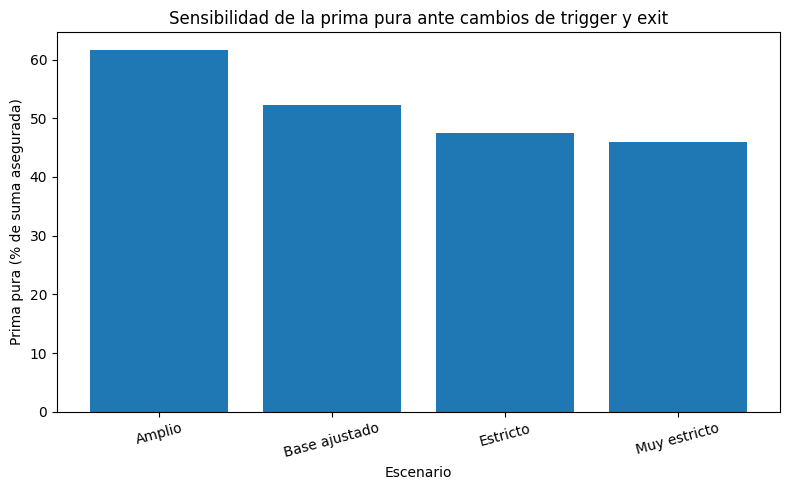

In [30]:
# =========================================================
# FIGURA: SENSIBILIDAD DE PRIMA PURA EN %
# =========================================================

plt.figure(figsize=(8, 5))

valores_pct = resumen_escenarios_1pago["prima_pura_pct"] * 100

plt.bar(resumen_escenarios_1pago["escenario"], valores_pct)

plt.xlabel("Escenario")
plt.ylabel("Prima pura (% de suma asegurada)")
plt.title("Sensibilidad de la prima pura ante cambios de trigger y exit")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    os.path.join(CARPETA_SALIDA, "figura_sensibilidad_prima_pura_pago_unico.png"),
    dpi=300
)

plt.show()

Recalcular capa de reaseguro no proporcional

In [31]:
# CAPA DE REASEGURO NO PROPORCIONAL CON PAGO ÚNICO ANUAL
agregado = portafolio_anual_1pago.copy()

# Dado que hay pocos años, uso percentiles sobre la serie disponible como ejercicio preliminar.
# Para una tarifa comercial se requeriría una serie histórica más larga.
PRIORIDAD_Q = 0.80
LIMITE_Q = 0.99

prioridad = agregado["pago_total"].quantile(PRIORIDAD_Q)
pago_extremo = agregado["pago_total"].quantile(LIMITE_Q)

limite = pago_extremo - prioridad

# Regla de seguridad si el límite queda demasiado pequeño
if limite <= 0:
    limite = agregado["pago_total"].max() - prioridad

agregado["recuperacion_reaseguro"] = np.minimum(
    np.maximum(agregado["pago_total"] - prioridad, 0),
    limite
)

agregado["retencion_cedente"] = (
    agregado["pago_total"] - agregado["recuperacion_reaseguro"]
)

prima_pura_reaseguro = agregado["recuperacion_reaseguro"].mean()

print(f"Prioridad: {prioridad:,.2f}")
print(f"Límite: {limite:,.2f}")
print(f"Prima pura de la capa reasegurada: {prima_pura_reaseguro:,.2f}")

display(agregado)

agregado.to_csv(
    os.path.join(CARPETA_SALIDA, "estructura_reaseguro_pago_unico_anual.csv"),
    index=False
)

Prioridad: 77,498.48
Límite: 27,151.75
Prima pura de la capa reasegurada: 4,525.29


,anio,pago_total,municipios,eventos_observados,municipios_activados,exposicion_total,burning_cost_pct,recuperacion_reaseguro,retencion_cedente
0,2019,55326.227292,1120,26,812,112000.0,0.493984,0.000000,55326.227292
1,2020,59751.029514,1120,53,811,112000.0,0.533491,0.000000,59751.029514
2,2021,58606.362552,1120,88,808,112000.0,0.523271,0.000000,58606.362552
3,2022,106079.275893,1120,93,1099,112000.0,0.947136,27151.754234,78927.521659
4,2023,56365.719544,1120,43,731,112000.0,0.503265,0.000000,56365.719544
5,2024,77498.481963,1120,62,899,112000.0,0.691951,0.000000,77498.481963


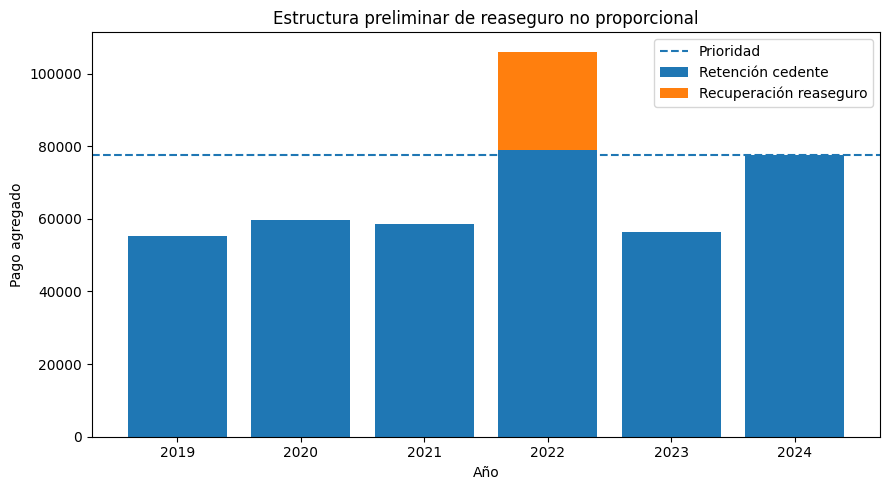

In [32]:
# =========================================================
# FIGURA: CAPA DE REASEGURO CORREGIDA
# =========================================================

plt.figure(figsize=(9, 5))

plt.bar(
    agregado["anio"],
    agregado["retencion_cedente"],
    label="Retención cedente"
)

plt.bar(
    agregado["anio"],
    agregado["recuperacion_reaseguro"],
    bottom=agregado["retencion_cedente"],
    label="Recuperación reaseguro"
)

plt.axhline(prioridad, linestyle="--", label="Prioridad")

plt.xlabel("Año")
plt.ylabel("Pago agregado")
plt.title("Estructura preliminar de reaseguro no proporcional")
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(CARPETA_SALIDA, "figura_capa_reaseguro_pago_unico_anual.png"),
    dpi=300
)

plt.show()

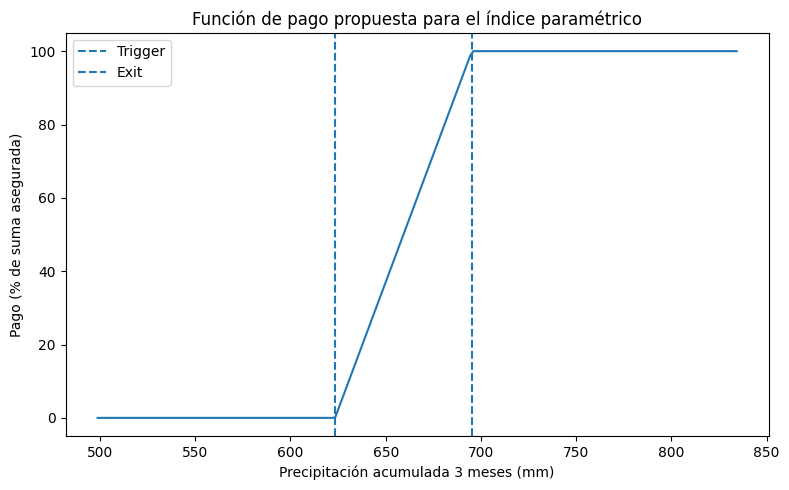

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.axvline(trigger_mediano, linestyle="--", label="Trigger")
plt.axvline(exit_mediano, linestyle="--", label="Exit")

plt.xlabel("Precipitación acumulada 3 meses (mm)")
plt.ylabel("Pago (% de suma asegurada)")
plt.title("Función de pago propuesta para el índice paramétrico")
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(CARPETA_SALIDA, "figura_funcion_pago_parametrica_final.png"),
    dpi=300
)

plt.show()